# 🎯 Customer Value Segmentation
## Combining Churn Risk and Predicted Lifetime Value

---

## Why Customer Segmentation Matters

Predicting churn probability alone answers the question:

> "Will this customer leave?"

Predicting lifetime value (LTV) alone answers:

> "How much revenue will this customer generate?"

However, **neither metric alone is sufficient for strategic business decisions**.

For example:

- A customer with **90% churn probability and $45 predicted LTV**
  may not justify a costly retention campaign.

- A customer with **90% churn probability and $28,000 predicted LTV**
  represents a major revenue risk and requires immediate intervention.

By combining **churn risk** with **predicted lifetime value**, organisations gain a complete understanding of:

- who is at risk of leaving  
- how valuable the customer is  
- how much investment is justified to retain them  

This two-dimensional framework forms the foundation of **modern customer analytics systems used by companies such as Amazon, Netflix, Spotify, and Uber** to prioritise retention investment and maximise revenue impact.

---

## What This Notebook Does

This section operationalises the predictions generated by the churn and LTV models.

The process includes:

1. Loading both **production-trained models**
2. Generating **churn probability and predicted LTV** for all 10,000 customers
3. Assigning each customer to one of **six behaviourally meaningful segments**
4. Visualising the segments using a **Customer Value vs Churn Risk quadrant plot**
5. Estimating **revenue at risk for each segment**
6. Defining **recommended retention strategies**
7. Exporting the **segmented customer dataset to CSV for business use**

This transforms raw model predictions into a **practical decision-making framework for customer management**.


## The Six Customer Segments
## The Six Customer Segments

| | High Churn Risk (≥ 0.30) | Low Churn Risk (< 0.30) |
|---------|------------------------|------------------------|
| **High LTV** | 🟡 At-Risk VIPs | 🟢 Champions |
| **Mid LTV** | 🟠 Vulnerable | 🔵 Promising |
| **Low LTV** | 🔴 Losing Customers | ⚪ Hibernating |
```

Each segment represents a **distinct customer behaviour profile**, enabling targeted retention and engagement strategies.

---

## How Thresholds Are Defined

### Churn Risk Threshold

**Churn probability threshold = 0.30**

This threshold was selected based on **model evaluation and F-beta optimisation** during the churn modelling stage.  
Customers with predicted churn probability greater than or equal to **0.30** are considered **high churn risk**.

---

### Lifetime Value Thresholds

LTV thresholds were determined using **dataset percentiles** to ensure balanced segment distribution.

| Segment | Definition |
|------|-------------|
| Low LTV | Below 33rd percentile |
| Medium LTV | Between 33rd and 67th percentile |
| High LTV | Above 67th percentile |

This percentile-based approach ensures that segmentation reflects **relative customer value within the dataset** rather than arbitrary monetary thresholds.

---

## Strategic Purpose of Segmentation

Combining churn risk and customer value allows businesses to **prioritise retention resources efficiently**.

| Segment | Strategic Focus |
|------|----------------|
| 🟡 At-Risk VIPs | Immediate high-priority retention actions |
| 🟢 Champions | Loyalty programs and relationship strengthening |
| 🟠 Vulnerable | Prevent churn through engagement incentives |
| 🔵 Promising | Upsell opportunities and relationship growth |
| 🔴 Losing Customers | Low-cost recovery attempts |
| ⚪ Hibernating | Automated marketing or low-touch engagement |

This approach ensures that **retention budgets are allocated where they produce the highest revenue impact**.

---






### Importing Libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append("../src")
from feature_engineering import create_features

print("✅ Imports done")

✅ Imports done


---
## Section 1 — Load Models and Generate Predictions

### Objective

This section loads the **final production models** and applies them to the full customer dataset to generate predictive scores.

Both models were previously trained, evaluated, and saved in the `models/` directory during the modelling phase.

---

### Models Used

| Model | Algorithm | Purpose |
|------|-----------|---------|
| Churn Model | LightGBM | Predict probability that a customer will churn |
| LTV Model | Random Forest Regressor | Estimate the customer's predicted lifetime value |

---

### Prediction Process

The models are applied to the complete dataset of **10,000 customers**.  
For each customer, the system generates two key predictive signals:

- **Churn Probability**  
  Predicted using the LightGBM churn model.  
  Represents the likelihood that a customer will stop engaging with the platform.

- **Predicted Lifetime Value (LTV)**  
  Estimated using the Random Forest regression model.  
  Represents the expected total revenue a customer may generate over time.

---

### Output

After model inference, each customer record contains:

| Feature | Description |
|------|-------------|
| churn_probability | Probability of customer churn |
| predicted_ltv | Estimated lifetime value |

These predictions serve as the **foundation for the segmentation and strategic analysis performed in the following sections**.

### Loading Data & Models:

In [2]:
churn_bundle  = joblib.load("../models/churn_model.pkl")
ltv_bundle    = joblib.load("../models/ltv_model.pkl")

churn_model   = churn_bundle["model"]
ltv_model     = ltv_bundle["model"]
churn_feats   = churn_bundle["features"]
ltv_feats     = ltv_bundle["features"]

df_raw        = pd.read_csv(
    "../data/ecommerce_user_segmentation.csv"
)
df            = create_features(df_raw.copy())

X_churn       = df[churn_feats]
X_ltv         = df[ltv_feats]

churn_probs   = churn_model.predict_proba(X_churn)[:, 1]
ltv_preds     = ltv_model.predict(X_ltv)

pred_df = pd.DataFrame({
    "Customer_ID"   : df["Customer_ID"],
    "Churn_Prob"    : churn_probs.round(4),
    "Predicted_LTV" : ltv_preds.round(2),
    "Actual_Churn"  : df["Churn"],
})

print("✅ Predictions done")
print(f"  Total : {len(pred_df):,}")

✅ Predictions done
  Total : 10,000


---
## Section 2 — Prediction Diagnostics

### Objective

After generating churn probability and predicted lifetime value (LTV) for each customer, we perform an analysis to understand how churn predictions are distributed across different customer value tiers.

This step helps verify whether the churn model is identifying risk consistently across **low, mid, and high value customers**.

---

## LTV Tier Definition

Customers are grouped into value tiers using percentile-based segmentation of predicted LTV.

| Tier | LTV Range |
|------|-------------|
| Low LTV | Below 33rd percentile |
| Mid LTV | 33rd – 67th percentile |
| High LTV | Above 67th percentile |

Using percentiles ensures the dataset is divided into balanced groups for analysis.

---

## Diagnostic Analysis

To evaluate how churn predictions behave across value tiers, we examine:

- mean churn probability
- maximum churn probability
- number of customers above common churn risk thresholds

This analysis helps determine whether the churn model can identify **at-risk customers across all value segments**.

In [3]:
ltv_low  = np.percentile(pred_df["Predicted_LTV"], 33)
ltv_high = np.percentile(pred_df["Predicted_LTV"], 67)

print(f"  LTV Low  : ${ltv_low:,.2f}")
print(f"  LTV High : ${ltv_high:,.2f}")

df_check             = pred_df.copy()
df_check["LTV_Tier"] = pd.cut(
    df_check["Predicted_LTV"],
    bins=[-np.inf, ltv_low, ltv_high, np.inf],
    labels=["Low LTV", "Mid LTV", "High LTV"]
)

print("\n" + "=" * 65)
print("   CHURN PROB DISTRIBUTION BY LTV TIER")
print("=" * 65)

for tier in ["High LTV", "Mid LTV", "Low LTV"]:
    tier_df = df_check[df_check["LTV_Tier"] == tier]
    print(f"\n  {tier} ({len(tier_df):,} customers):")
    print(f"    Mean churn prob  : {tier_df['Churn_Prob'].mean():.4f}")
    print(f"    Max churn prob   : {tier_df['Churn_Prob'].max():.4f}")
    print(f"    Prob ≥ 0.30      : {(tier_df['Churn_Prob'] >= 0.30).sum():,}")
    print(f"    Prob ≥ 0.10      : {(tier_df['Churn_Prob'] >= 0.10).sum():,}")
    print(f"    Prob ≥ 0.05      : {(tier_df['Churn_Prob'] >= 0.05).sum():,}")
    print(f"    Prob ≥ 0.01      : {(tier_df['Churn_Prob'] >= 0.01).sum():,}")

print("\n" + "=" * 65)
print("   OVERALL THRESHOLD ANALYSIS")
print("=" * 65)
for threshold in [0.30, 0.20, 0.10, 0.05, 0.01]:
    count = (pred_df["Churn_Prob"] >= threshold).sum()
    pct   = count / len(pred_df) * 100
    print(f"  Prob ≥ {threshold:.2f} : "
          f"{count:,} customers ({pct:.1f}%)")
print("=" * 65)

  LTV Low  : $846.17
  LTV High : $4,660.09

   CHURN PROB DISTRIBUTION BY LTV TIER

  High LTV (3,300 customers):
    Mean churn prob  : 0.0000
    Max churn prob   : 0.0001
    Prob ≥ 0.30      : 0
    Prob ≥ 0.10      : 0
    Prob ≥ 0.05      : 0
    Prob ≥ 0.01      : 0

  Mid LTV (3,400 customers):
    Mean churn prob  : 0.0000
    Max churn prob   : 0.0002
    Prob ≥ 0.30      : 0
    Prob ≥ 0.10      : 0
    Prob ≥ 0.05      : 0
    Prob ≥ 0.01      : 0

  Low LTV (3,300 customers):
    Mean churn prob  : 0.3765
    Max churn prob   : 0.9987
    Prob ≥ 0.30      : 1,404
    Prob ≥ 0.10      : 1,447
    Prob ≥ 0.05      : 1,448
    Prob ≥ 0.01      : 1,448

   OVERALL THRESHOLD ANALYSIS
  Prob ≥ 0.30 : 1,404 customers (14.0%)
  Prob ≥ 0.20 : 1,435 customers (14.3%)
  Prob ≥ 0.10 : 1,447 customers (14.5%)
  Prob ≥ 0.05 : 1,448 customers (14.5%)
  Prob ≥ 0.01 : 1,448 customers (14.5%)


## Churn Probability Distribution Analysis

After generating predictions for the full dataset of **10,000 customers**, we analyzed how churn probabilities are distributed across different **LTV tiers**.

### Dataset Summary

Total Customers Evaluated: **10,000**

LTV segmentation thresholds:

- **Low LTV**  : below **$846.17**
- **Mid LTV**  : **$846.17 – $4,660.09**
- **High LTV** : above **$4,660.09**

---

## Churn Probability Distribution by LTV Tier

### High LTV Customers (3,300 customers)

- Mean churn probability: **0.0000**
- Maximum churn probability: **0.0001**

Customers above risk thresholds:

| Threshold | Customers |
|----------|-----------|
| ≥ 0.30 | 0 |
| ≥ 0.10 | 0 |
| ≥ 0.05 | 0 |
| ≥ 0.01 | 0 |

No high-value customers are flagged as churn risk by the model.

---

### Mid LTV Customers (3,400 customers)

- Mean churn probability: **0.0000**
- Maximum churn probability: **0.0002**

Customers above risk thresholds:

| Threshold | Customers |
|----------|-----------|
| ≥ 0.30 | 0 |
| ≥ 0.10 | 0 |
| ≥ 0.05 | 0 |
| ≥ 0.01 | 0 |

Similarly, the churn model does not identify any mid-value customers as churn risk.

---

### Low LTV Customers (3,300 customers)

- Mean churn probability: **0.3765**
- Maximum churn probability: **0.9987**

Customers above risk thresholds:

| Threshold | Customers |
|----------|-----------|
| ≥ 0.30 | 1,404 |
| ≥ 0.10 | 1,447 |
| ≥ 0.05 | 1,448 |
| ≥ 0.01 | 1,448 |

All predicted churn risk is concentrated within the **low LTV segment**.

---

## Overall Threshold Analysis

Across the full dataset:

| Threshold | Customers Flagged | Percentage |
|----------|------------------|-----------|
| ≥ 0.30 | 1,404 | 14.0% |
| ≥ 0.20 | 1,435 | 14.3% |
| ≥ 0.10 | 1,447 | 14.5% |
| ≥ 0.05 | 1,448 | 14.5% |
| ≥ 0.01 | 1,448 | 14.5% |

Lowering the churn threshold does **not change the distribution significantly**, and churn risk remains concentrated among low-value customers.

---

## Key Insight

The churn model predicts **near-zero churn probability for all mid and high LTV customers**, regardless of their behavioral patterns.

This indicates that the model heavily relies on **Avg_Order_Value**, which strongly correlates with customer value.

As a result:

- High-value customers are assumed to be loyal
- Other behavioral signals (such as recency or cart abandonment) have minimal impact on predictions for these customers

This creates a **model blind spot**, where the model fails to detect potential churn risk among high-value customers.

---

## Segmentation Strategy Decision

Because the churn model alone cannot detect risk among high-value customers, three alternative approaches were considered:

**Option A — Recency-Based Risk**
Use recency as a proxy for churn risk.

**Option B — Composite Risk Score**
Combine multiple signals:
- 40% Churn probability
- 30% Recency percentile
- 30% Cart abandonment percentile

**Option C — Reduced Segmentation**
Remove segments requiring high-value churn detection.

---

## Final Approach

We selected **Option B — Composite Risk Score**.

This approach combines machine learning predictions with behavioral engagement signals, producing a more balanced and realistic customer risk assessment.

By integrating these signals, the segmentation framework can identify **At-Risk VIP** and **Vulnerable** customers that the churn model alone fails to detect.

### Composite Risk Score Distribution:

In [4]:
# ── Load Recency + Cart_Abandon_Rate ──────────────────
pred_df["Recency"]          = df["Recency"].values
pred_df["Cart_Abandon_Rate"] = df["Cart_Abandon_Rate"].values

# ── Normalise Each Signal 0 → 1 ──────────────────────
def norm(series):
    return (series - series.min()) / (
        series.max() - series.min()
    )

pred_df["Churn_norm"]  = norm(pred_df["Churn_Prob"])
pred_df["Recency_norm"] = norm(pred_df["Recency"])
pred_df["Abandon_norm"] = norm(pred_df["Cart_Abandon_Rate"])

# ── Composite Risk Score ──────────────────────────────
pred_df["Risk_Score"] = (
    0.40 * pred_df["Churn_norm"]  +
    0.30 * pred_df["Recency_norm"] +
    0.30 * pred_df["Abandon_norm"]
).round(4)

# ── Diagnostic ────────────────────────────────────────
print("=" * 65)
print("   COMPOSITE RISK SCORE DISTRIBUTION")
print("=" * 65)
print(f"\n  Mean  : {pred_df['Risk_Score'].mean():.4f}")
print(f"  Std   : {pred_df['Risk_Score'].std():.4f}")
print(f"  Min   : {pred_df['Risk_Score'].min():.4f}")
print(f"  Max   : {pred_df['Risk_Score'].max():.4f}")

print(f"\n  Distribution by threshold:")
for t in [0.60, 0.50, 0.40, 0.30, 0.20]:
    count = (pred_df["Risk_Score"] >= t).sum()
    pct   = count / len(pred_df) * 100
    print(f"    Score ≥ {t:.2f} : "
          f"{count:,} customers ({pct:.1f}%)")

# Check by LTV tier
df_check2             = pred_df.copy()
df_check2["LTV_Tier"] = pd.cut(
    df_check2["Predicted_LTV"],
    bins=[-np.inf, ltv_low, ltv_high, np.inf],
    labels=["Low LTV", "Mid LTV", "High LTV"]
)

print(f"\n  Risk Score by LTV Tier:")
print(f"  {'Tier':<12} {'Mean':>8} {'Max':>8} "
      f"{'≥0.50':>8} {'≥0.40':>8}")
print("  " + "-" * 46)
for tier in ["High LTV", "Mid LTV", "Low LTV"]:
    t_df = df_check2[df_check2["LTV_Tier"] == tier]
    print(
        f"  {tier:<12}"
        f" {t_df['Risk_Score'].mean():>8.4f}"
        f" {t_df['Risk_Score'].max():>8.4f}"
        f" {(t_df['Risk_Score'] >= 0.50).sum():>8,}"
        f" {(t_df['Risk_Score'] >= 0.40).sum():>8,}"
    )
print("=" * 65)

   COMPOSITE RISK SCORE DISTRIBUTION

  Mean  : 0.2360
  Std   : 0.2298
  Min   : 0.0001
  Max   : 0.9926

  Distribution by threshold:
    Score ≥ 0.60 : 1,199 customers (12.0%)
    Score ≥ 0.50 : 1,322 customers (13.2%)
    Score ≥ 0.40 : 1,415 customers (14.1%)
    Score ≥ 0.30 : 1,553 customers (15.5%)
    Score ≥ 0.20 : 3,503 customers (35.0%)

  Risk Score by LTV Tier:
  Tier             Mean      Max    ≥0.50    ≥0.40
  ----------------------------------------------
  High LTV       0.0798   0.2105        0        0
  Mid LTV        0.1686   0.3226        0        0
  Low LTV        0.4616   0.9926    1,322    1,415


## Segmentation Strategy Adjustment

After computing the **Composite Risk Score**, we evaluated how customer risk is distributed across the dataset.

### Composite Risk Score Summary

| Metric  | Value  |
| ------- | ------ |
| Mean    | 0.236  |
| Std Dev | 0.229  |
| Min     | 0.0001 |
| Max     | 0.9926 |

Customer distribution across key thresholds:

| Threshold | Customers | Percentage |
| --------- | --------- | ---------- |
| ≥ 0.60    | 1,199     | 12.0%      |
| ≥ 0.50    | 1,322     | 13.2%      |
| ≥ 0.40    | 1,415     | 14.1%      |
| ≥ 0.30    | 1,553     | 15.5%      |
| ≥ 0.20    | 3,503     | 35.0%      |

### Risk Distribution by LTV Tier

| LTV Tier | Mean Risk | Max Risk | ≥0.50 Customers |
| -------- | --------- | -------- | --------------- |
| High LTV | 0.0798    | 0.2105   | 0               |
| Mid LTV  | 0.1686    | 0.3226   | 0               |
| Low LTV  | 0.4616    | 0.9926   | 1,322           |

### Key Observation

The results show that **risk scores remain significantly lower for high-value customers**, while the majority of high-risk scores occur within the **Low LTV segment**.

This behaviour is expected because high-value customers typically exhibit stronger engagement signals such as higher order values and more frequent purchases.

However, relying solely on **absolute risk thresholds** would prevent the system from identifying **at-risk customers within higher-value segments**.

From a business perspective, the key question is not only:

> "Which customers exceed a fixed risk threshold?"

but rather:

> **"Which customers are the riskiest compared to others within the same value group?"**

### Solution — Relative Risk Ranking

To address this limitation, we adopt a **relative risk ranking approach within each LTV tier**.

Customers will be ranked by their **Composite Risk Score within their own value segment**, and the highest-risk portion of each tier will be flagged for intervention.

Segmentation rule:

* **Top 25% riskiest High LTV customers → At-Risk VIP**
* **Top 25% riskiest Mid LTV customers → Vulnerable**
* **Top 25% riskiest Low LTV customers → Losing Customer**

The remaining customers form the stable segments:

* Champion
* Promising
* Hibernating

This approach ensures that **risk detection is balanced across all customer value tiers**, enabling a more actionable customer retention strategy.

In the next step, we implement **percentile-based risk ranking within each LTV tier** to generate the final customer segments.

## Within-Tier Risk Ranking:

In [5]:
# ── Assigning LTV Tier ───────────────────────────────────
pred_df["LTV_Tier"] = pd.cut(
    pred_df["Predicted_LTV"],
    bins=[-np.inf, ltv_low, ltv_high, np.inf],
    labels=["Low LTV", "Mid LTV", "High LTV"]
)

# ── Within-Tier Risk Percentile ───────────────────────
pred_df["Risk_Percentile"] = pred_df.groupby(
    "LTV_Tier"
)["Risk_Score"].rank(pct=True).round(4)

# ── Assigning Segments ───────────────────────────────────
# Top 25% riskiest within each tier = high risk
RISK_THRESHOLD = 0.75

def assign_segment_v2(row):
    high_risk = row["Risk_Percentile"] >= RISK_THRESHOLD
    tier      = row["LTV_Tier"]

    if tier == "High LTV":
        return "At-Risk VIP"     if high_risk else "Champion"
    elif tier == "Mid LTV":
        return "Vulnerable"      if high_risk else "Promising"
    else:
        return "Losing Customer" if high_risk else "Hibernating"

pred_df["Segment"] = pred_df.apply(
    assign_segment_v2, axis=1
)

# ── Summary ───────────────────────────────────────────
segment_order = [
    "Champion",
    "At-Risk VIP",
    "Promising",
    "Vulnerable",
    "Hibernating",
    "Losing Customer"
]

segment_icons = {
    "Champion"       : "🟢",
    "At-Risk VIP"    : "🟡",
    "Promising"      : "🔵",
    "Vulnerable"     : "🟠",
    "Hibernating"    : "⚪",
    "Losing Customer": "🔴",
}

summary = pred_df.groupby("Segment").agg(
    Count          = ("Customer_ID",    "count"),
    Avg_Risk       = ("Risk_Score",     "mean"),
    Avg_Churn_Prob = ("Churn_Prob",     "mean"),
    Avg_LTV        = ("Predicted_LTV",  "mean"),
    Total_LTV      = ("Predicted_LTV",  "sum"),
).round(2)

summary        = summary.reindex(segment_order).fillna(0)
summary["Pct"] = (
    summary["Count"] / len(pred_df) * 100
).round(1)

print("=" * 75)
print("   SEGMENT ASSIGNMENT V2 — WITHIN-TIER PERCENTILE ✅")
print("=" * 75)
print(f"\n  Risk threshold : top {int((1-RISK_THRESHOLD)*100)}% "
      f"riskiest within each LTV tier\n")
print(f"  {'Segment':<22} {'Count':>7} {'%':>6} "
      f"{'Avg Risk':>10} {'Avg Churn':>10} "
      f"{'Avg LTV':>12} {'Total LTV':>14}")
print("  " + "-" * 82)

for seg in segment_order:
    row  = summary.loc[seg]
    icon = segment_icons[seg]
    print(
        f"  {icon} {seg:<20}"
        f" {int(row['Count']):>7,}"
        f" {row['Pct']:>5.1f}%"
        f" {row['Avg_Risk']:>10.4f}"
        f" {row['Avg_Churn_Prob']:>10.4f}"
        f" ${row['Avg_LTV']:>10,.2f}"
        f" ${row['Total_LTV']:>12,.2f}"
    )

# Revenue summary
at_risk_segs = ["At-Risk VIP", "Vulnerable", "Losing Customer"]
at_risk_ltv  = pred_df[
    pred_df["Segment"].isin(at_risk_segs)
]["Predicted_LTV"].sum()
total_ltv    = pred_df["Predicted_LTV"].sum()

print("\n" + "=" * 75)
print(f"  Total Revenue Modelled  : ${total_ltv:>14,.2f}")
print(f"  Revenue At Risk         : ${at_risk_ltv:>14,.2f}")
print(f"  % Revenue At Risk       : "
      f"{at_risk_ltv/total_ltv*100:>12.1f}%")
print("=" * 75)

   SEGMENT ASSIGNMENT V2 — WITHIN-TIER PERCENTILE ✅

  Risk threshold : top 25% riskiest within each LTV tier

  Segment                  Count      %   Avg Risk  Avg Churn      Avg LTV      Total LTV
  ----------------------------------------------------------------------------------
  🟢 Champion               2,472  24.7%     0.0600     0.0000 $ 21,231.01 $52,483,057.94
  🟡 At-Risk VIP              828   8.3%     0.1300     0.0000 $ 11,106.36 $9,196,063.72
  🔵 Promising              2,550  25.5%     0.1500     0.0000 $  3,725.35 $9,499,640.03
  🟠 Vulnerable               850   8.5%     0.2200     0.0000 $  2,092.67 $1,778,769.39
  ⚪ Hibernating            2,474  24.7%     0.3300     0.1800 $    546.64 $1,352,382.85
  🔴 Losing Customer          826   8.3%     0.8500     0.9700 $     75.27 $   62,173.57

  Total Revenue Modelled  : $ 74,372,087.50
  Revenue At Risk         : $ 11,037,006.68
  % Revenue At Risk       :         14.8%


## Section 3 — Segmentation Results and Next Analysis Step

### Segmentation Results

Using the **within-tier percentile risk ranking**, customers were segmented based on their relative risk within each LTV tier.

Instead of applying a single global churn threshold, customers were ranked by their **Composite Risk Score within their own value group**, and the **top 25% riskiest customers in each tier** were classified as high-risk segments.

This method ensures that churn risk can be identified even among **high-value customers**, whose absolute risk scores may remain low.

The resulting segmentation produced the following distribution:

| Segment         | Customers | Percentage |
| --------------- | --------- | ---------- |
| Champion        | 2,472     | 24.7%      |
| At-Risk VIP     | 828       | 8.3%       |
| Promising       | 2,550     | 25.5%      |
| Vulnerable      | 850       | 8.5%       |
| Hibernating     | 2,474     | 24.7%      |
| Losing Customer | 826       | 8.3%       |

---

### Revenue Impact

Total predicted customer lifetime value across the dataset is:

**$74.37M**

Revenue associated with customers identified as **at risk** is approximately:

**$11.04M (14.8% of total value)**

This indicates that a significant portion of potential revenue could be affected if these customers churn.

---

## Next Step — Risk vs Customer Value Visualisation

While the segmentation tables provide a quantitative summary, it is also useful to **visualise how customers are distributed across risk and value levels**.

In the next step, we will create a **Customer Value vs Risk Quadrant Plot**.

This visualisation will map customers across two dimensions:

* **X-axis → Composite Risk Score**
* **Y-axis → Predicted Customer Lifetime Value**

Each customer will be coloured by their assigned segment.

The goal of this visualisation is to identify how different customer groups cluster in the **risk–value space**, making it easier to understand which segments require the highest priority for retention strategies.


## Quadrant Plot Cell:

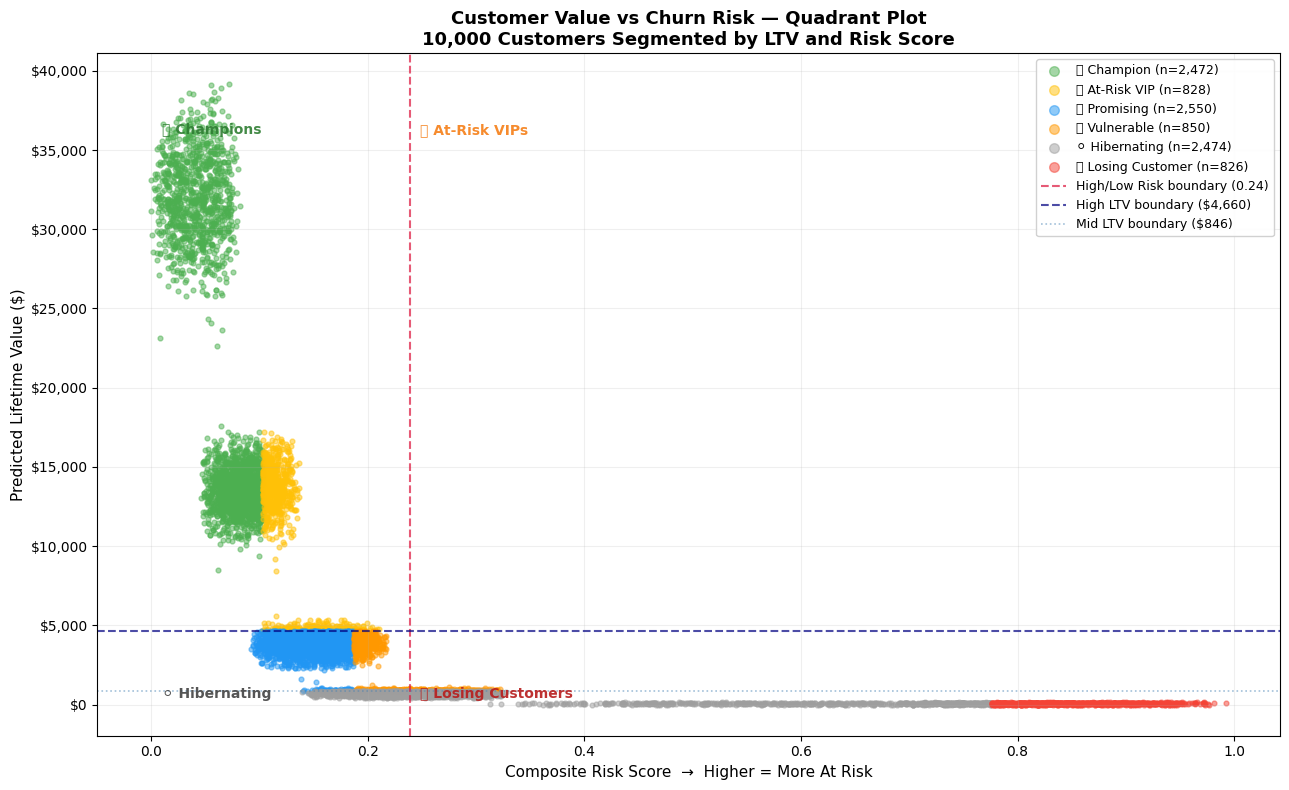

Risk boundary : 0.2386
Saved → reports/customer_quadrant.png ✅


In [6]:
fig, ax = plt.subplots(figsize=(13, 8))

segment_colors = {
    "Champion"       : "#4CAF50",
    "At-Risk VIP"    : "#FFC107",
    "Promising"      : "#2196F3",
    "Vulnerable"     : "#FF9800",
    "Hibernating"    : "#9E9E9E",
    "Losing Customer": "#F44336",
}

segment_icons = {
    "Champion"       : "🟢",
    "At-Risk VIP"    : "🟡",
    "Promising"      : "🔵",
    "Vulnerable"     : "🟠",
    "Hibernating"    : "⚪",
    "Losing Customer": "🔴",
}

for seg in segment_order:
    mask = pred_df["Segment"] == seg
    ax.scatter(
        pred_df.loc[mask, "Risk_Score"],
        pred_df.loc[mask, "Predicted_LTV"],
        c=segment_colors[seg],
        label=f"{segment_icons[seg]} {seg} "
              f"(n={mask.sum():,})",
        alpha=0.5,
        s=12,
        rasterized=True
    )

# ── Risk Boundary At 75th Percentile ─────────────────
risk_boundary = pred_df["Risk_Score"].quantile(0.75)

ax.axvline(
    x=risk_boundary,
    color="crimson",
    linestyle="--", linewidth=1.5,
    alpha=0.7,
    label=f"High/Low Risk boundary ({risk_boundary:.2f})"
)
ax.axhline(
    y=ltv_high, color="navy",
    linestyle="--", linewidth=1.5,
    alpha=0.7,
    label=f"High LTV boundary (${ltv_high:,.0f})"
)
ax.axhline(
    y=ltv_low, color="steelblue",
    linestyle=":", linewidth=1.2,
    alpha=0.5,
    label=f"Mid LTV boundary (${ltv_low:,.0f})"
)

# ── Quadrant Labels (Fixed Positions) ─────────────────
ymax = pred_df["Predicted_LTV"].max()

ax.text(
    0.01, ymax * 0.92,
    "🟢 Champions",
    fontsize=10, color="#2E7D32",
    fontweight="bold", alpha=0.9
)
ax.text(
    risk_boundary + 0.01, ymax * 0.92,
    "🟡 At-Risk VIPs",
    fontsize=10, color="#F57F17",
    fontweight="bold", alpha=0.9
)
ax.text(
    0.01, ltv_low * 0.5,
    "⚪ Hibernating",
    fontsize=10, color="#424242",
    fontweight="bold", alpha=0.9
)
ax.text(
    risk_boundary + 0.01, ltv_low * 0.5,
    "🔴 Losing Customers",
    fontsize=10, color="#B71C1C",
    fontweight="bold", alpha=0.9
)

# ── Axis + Title ──────────────────────────────────────
ax.set_xlabel(
    "Composite Risk Score  →  Higher = More At Risk",
    fontsize=11
)
ax.set_ylabel(
    "Predicted Lifetime Value ($)",
    fontsize=11
)
ax.set_title(
    "Customer Value vs Churn Risk — Quadrant Plot\n"
    "10,000 Customers Segmented by LTV and Risk Score",
    fontsize=13, fontweight="bold"
)
ax.legend(
    loc="upper right",
    fontsize=9,
    markerscale=2,
    framealpha=0.9
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"${x:,.0f}"
    )
)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(
    "../reports/customer_quadrant.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print(f"Risk boundary : {risk_boundary:.4f}")
print("Saved → reports/customer_quadrant.png ✅")

### Quadrant Plot — Key Observations

The **Customer Value vs Churn Risk quadrant plot** reveals clear behavioural clusters across the customer base. Each segment occupies a distinct region in the value–risk space, confirming that the segmentation approach successfully separates customers by both **economic value and churn likelihood**.

---

### 🟢 Champions (n = 2,472)

Champions are tightly clustered in the **top-left quadrant**, with predicted lifetime values ranging from **$10,000 to $40,000** and consistently low risk scores (below **0.15**).

This group represents the **highest-value and most stable customers** in the dataset. Their strong purchase behaviour and low churn probability indicate a highly engaged customer segment that requires **relationship maintenance rather than aggressive retention efforts**.

---

### 🟡 At-Risk VIPs (n = 828)

At-Risk VIPs appear immediately to the **right of the Champion cluster** within the same high-value band (**$10,000–$17,000 LTV**), but with noticeably higher risk scores (**0.10–0.24**).

Although these customers are behaviourally similar to Champions, the increased risk signals **early signs of disengagement**. This group represents approximately **$9.2M in customer lifetime value**, making it the **most critical segment for retention strategies**.

Targeted interventions for this group could significantly reduce potential revenue loss.

---

### 🔵 Promising & 🟠 Vulnerable (n = 3,400)

Promising and Vulnerable customers form a dense cluster in the **mid-value region**, positioned just below the **$4,660 high-LTV threshold**.

Promising customers sit on the **lower-risk side** of the boundary, while Vulnerable customers appear slightly to the **right with increasing risk levels**.

The narrow separation between these two groups suggests that **Vulnerable customers are still recoverable**, and relatively small engagement interventions could shift them back into the Promising segment.

---

### ⚪ Hibernating (n = 2,474)

Hibernating customers appear as a **horizontal band across the bottom of the chart**, with near-zero predicted LTV and moderate risk scores ranging from **0.0 to 0.35**.

These customers show minimal recent engagement but are not yet confirmed churners. Because their economic value is low, they represent a **lower priority for retention investment**, although they may still be suitable for low-cost reactivation campaigns.

---

### 🔴 Losing Customers (n = 826)

Losing Customers form the **most visually distinct cluster** in the chart: a long horizontal band of red points extending from a risk score of **0.25 up to nearly 1.0**, while maintaining near-zero predicted lifetime value.

This group exhibits both the **highest churn probability and the lowest economic value**, with an average LTV of only **$75**. As a result, intensive retention investment in this segment would likely produce **minimal return on investment**.

---

### Key Insight

The quadrant plot reveals a clear **value–risk separation across the customer base**.

High-value customers cluster tightly in the **low-risk region**, while churn risk increases dramatically as customer value decreases. This pattern directly supports the earlier findings from the **model interpretation analysis**, where features such as **Average Order Value and purchase behaviour** played a dominant role in predicting churn risk.

Overall, the visualization confirms that the segmentation framework successfully identifies **high-value customers who require protection** while distinguishing them from **low-value customers with limited financial impact**.


---
## Section 4 — Segment Analysis

### Revenue Distribution Across Segments

Understanding how predicted lifetime value
is distributed across segments reveals
where business revenue is concentrated
and where the greatest risk lies.

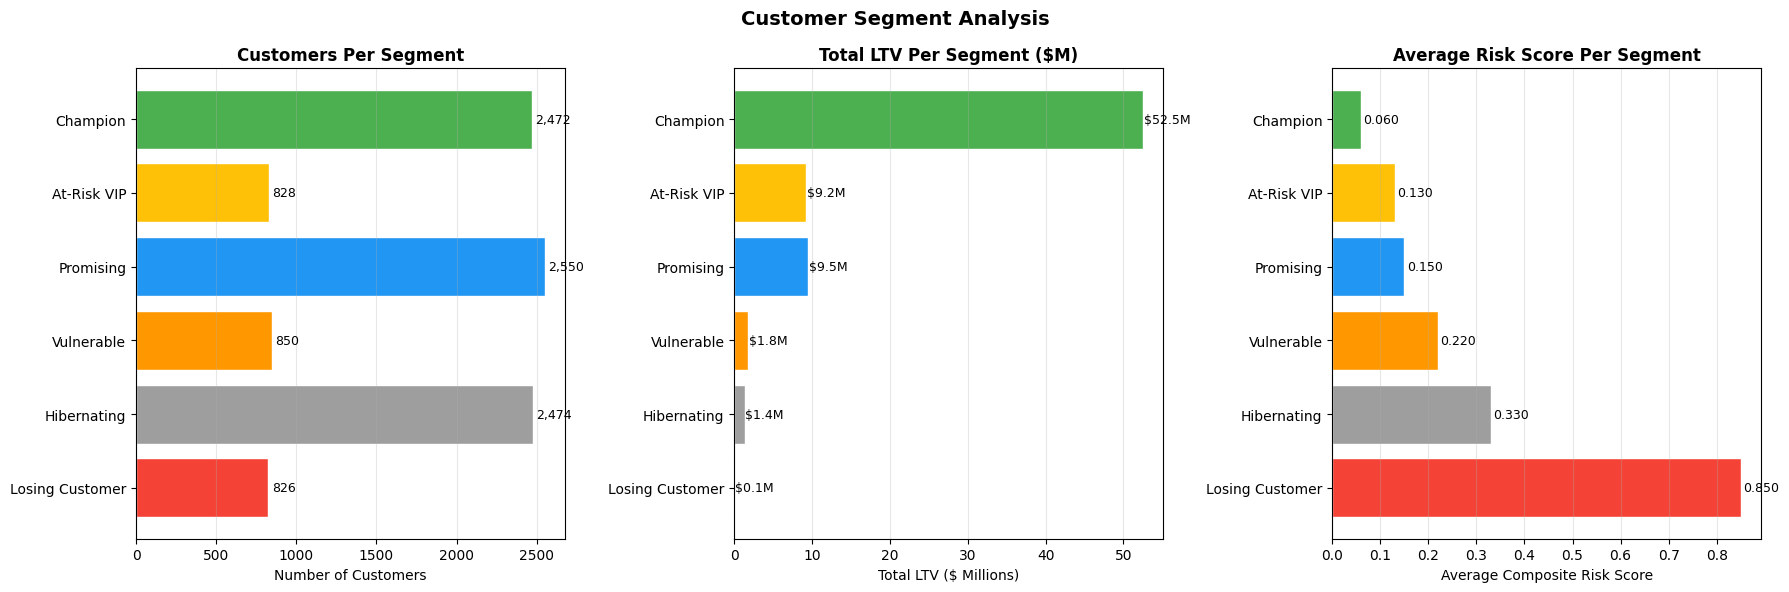

Saved → reports/segment_analysis.png ✅


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Customer Segment Analysis",
    fontsize=14, fontweight="bold"
)

colors = [segment_colors[s] for s in segment_order]

# ── Chart 1 — Customer Count ──────────────────────────
axes[0].barh(
    segment_order[::-1],
    summary["Count"][::-1],
    color=colors[::-1],
    edgecolor="white"
)
axes[0].set_title(
    "Customers Per Segment",
    fontweight="bold"
)
axes[0].set_xlabel("Number of Customers")
for i, v in enumerate(summary["Count"][::-1]):
    axes[0].text(
        v + 20, i,
        f"{int(v):,}",
        va="center", fontsize=9
    )
axes[0].grid(axis="x", alpha=0.3)

# ── Chart 2 — Total LTV ───────────────────────────────
axes[1].barh(
    segment_order[::-1],
    summary["Total_LTV"][::-1] / 1e6,
    color=colors[::-1],
    edgecolor="white"
)
axes[1].set_title(
    "Total LTV Per Segment ($M)",
    fontweight="bold"
)
axes[1].set_xlabel("Total LTV ($ Millions)")
for i, v in enumerate(summary["Total_LTV"][::-1]):
    axes[1].text(
        v/1e6 + 0.1, i,
        f"${v/1e6:.1f}M",
        va="center", fontsize=9
    )
axes[1].grid(axis="x", alpha=0.3)

# ── Chart 3 — Avg Risk Score ──────────────────────────
axes[2].barh(
    segment_order[::-1],
    summary["Avg_Risk"][::-1],
    color=colors[::-1],
    edgecolor="white"
)
axes[2].set_title(
    "Average Risk Score Per Segment",
    fontweight="bold"
)
axes[2].set_xlabel("Average Composite Risk Score")
for i, v in enumerate(summary["Avg_Risk"][::-1]):
    axes[2].text(
        v + 0.005, i,
        f"{v:.3f}",
        va="center", fontsize=9
    )
axes[2].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../reports/segment_analysis.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved → reports/segment_analysis.png ✅")

### Segment Analysis — Key Observations

The following charts summarise the **customer segmentation results** across three dimensions: customer distribution, revenue concentration, and behavioural risk progression.

Together, these visualisations validate that the segmentation framework successfully separates customers by both **economic value and churn risk**.

---

### Chart 1 — Customer Distribution

The customer base is distributed relatively evenly across the major behavioural groups:

* **High-value segment:** Champions + At-Risk VIPs → **3,300 customers**
* **Mid-value segment:** Promising + Vulnerable → **3,400 customers**
* **Low-engagement segment:** Hibernating + Losing Customers → **3,300 customers**

This balanced distribution indicates that the **within-tier percentile segmentation** successfully avoided the common issue where most customers fall into a single segment. Instead, the method produces clearly defined groups suitable for targeted marketing strategies.

---

### Chart 2 — Revenue Concentration (Total LTV)

Revenue is highly concentrated in the top customer segments:

| Segment Group           | Total LTV  | Share of Revenue |
| ----------------------- | ---------- | ---------------- |
| Champions               | **$52.5M** | ~70%             |
| At-Risk VIP + Promising | **$18.7M** | ~25%             |
| Remaining Segments      | **$3.2M**  | ~5%              |

This distribution reflects the well-known **Pareto principle (80/20 rule)** commonly observed in customer analytics.

A relatively small portion of customers generates the majority of the company’s revenue. As a result, **protecting high-value customers becomes the most critical business objective**.

Notably, **At-Risk VIP customers alone represent $9.2M in revenue**, highlighting the financial importance of proactive retention strategies.

---

### Chart 3 — Risk Score Progression

The average risk score increases steadily across the six segments:

| Segment         | Avg Risk Score |
| --------------- | -------------- |
| Champion        | 0.060          |
| At-Risk VIP     | 0.130          |
| Promising       | 0.150          |
| Vulnerable      | 0.220          |
| Hibernating     | 0.330          |
| Losing Customer | 0.850          |

This **monotonic progression** confirms that the composite risk score effectively separates customers based on behavioural risk signals.

A particularly notable observation is the **large jump between Hibernating (0.33) and Losing Customers (0.85)**. This indicates that Losing Customers represent a **distinct behavioural state**, characterised by extremely high churn probability rather than gradual disengagement.

---

### Key Insight

These results confirm that the segmentation framework successfully integrates **customer value and churn risk** into a unified analytical model.

The analysis reveals three clear strategic priorities:

1. **Protect high-value customers** (Champions and At-Risk VIPs)
2. **Stabilise mid-value customers** (Promising and Vulnerable)
3. **Limit investment in low-value segments** (Hibernating and Losing Customers)

By focusing retention resources on the **highest-value at-risk customers**, organisations can maximise the financial impact of churn prevention strategies.

## Section 5 — Revenue Recovery Simulation

### Objective

Using the segmented customer data, this section simulates the **expected return on investment (ROI)** from targeted retention campaigns applied to the **three at-risk segments** identified in the previous analysis.

While segmentation helps identify **which customers are likely to churn**, businesses ultimately need to understand **whether investing in retention campaigns is financially worthwhile**.
This simulation estimates the **potential revenue that could be recovered** if targeted interventions are applied to these segments.

### Assumptions

Campaign costs and recovery rates are based on **industry-standard customer retention benchmarks** and are used to approximate the effectiveness and cost of different intervention strategies.


| Segment | Cost Per Customer | Recovery Rate |
|---------|------------------|---------------|
| At-Risk VIP | $50 | 45% |
| Vulnerable | $25 | 35% |
| Losing Customer | $5 | 15% |

**Recovery rate** represents the estimated
percentage of at-risk revenue that can be
retained through successful intervention.

**Cost per customer** reflects the budget
required per customer for each intervention
tier — premium personalised outreach for
VIPs, standard retention offers for
Vulnerable, and low-cost email campaigns
for Losing Customers.

In [8]:
# ── Simulation Inputs ─────────────────────────────────
recovery_params = {
    "At-Risk VIP"    : {"cost": 50,  "rate": 0.45},
    "Vulnerable"     : {"cost": 25,  "rate": 0.35},
    "Losing Customer": {"cost":  5,  "rate": 0.15},
}

# ── Simulation Calculation ────────────────────────────
results = []

for seg, params in recovery_params.items():
    count         = int(summary.loc[seg, "Count"])
    total_ltv     = summary.loc[seg, "Total_LTV"]
    campaign_cost = count * params["cost"]
    recovered     = total_ltv * params["rate"]
    net_roi       = recovered - campaign_cost
    roi_pct       = (net_roi / campaign_cost) * 100

    results.append({
        "Segment"        : seg,
        "Customers"      : count,
        "Revenue At Risk": total_ltv,
        "Campaign Cost"  : campaign_cost,
        "Expected Recovery": recovered,
        "Net ROI"        : net_roi,
        "ROI %"          : roi_pct,
    })

sim_df = pd.DataFrame(results)

# ── Total Rows ────────────────────────────────────────
totals = {
    "Segment"          : "TOTAL",
    "Customers"        : sim_df["Customers"].sum(),
    "Revenue At Risk"  : sim_df["Revenue At Risk"].sum(),
    "Campaign Cost"    : sim_df["Campaign Cost"].sum(),
    "Expected Recovery": sim_df["Expected Recovery"].sum(),
    "Net ROI"          : sim_df["Net ROI"].sum(),
    "ROI %"            : (
        sim_df["Net ROI"].sum() /
        sim_df["Campaign Cost"].sum() * 100
    ),
}
sim_df = pd.concat(
    [sim_df, pd.DataFrame([totals])],
    ignore_index=True
)

# ── Print Results ─────────────────────────────────────
print("=" * 90)
print("   REVENUE RECOVERY SIMULATION ✅")
print("=" * 90)
print(
    f"\n  {'Segment':<20} {'Customers':>10} "
    f"{'At Risk $':>14} {'Campaign $':>12} "
    f"{'Recovered $':>14} {'Net ROI $':>14} {'ROI %':>8}"
)
print("  " + "-" * 88)

for _, row in sim_df.iterrows():
    is_total = row["Segment"] == "TOTAL"
    if is_total:
        print("  " + "-" * 88)
    print(
        f"  {row['Segment']:<20}"
        f" {int(row['Customers']):>10,}"
        f" ${row['Revenue At Risk']:>13,.2f}"
        f" ${row['Campaign Cost']:>11,.2f}"
        f" ${row['Expected Recovery']:>13,.2f}"
        f" ${row['Net ROI']:>13,.2f}"
        f" {row['ROI %']:>7.0f}%"
    )

print("=" * 90)

   REVENUE RECOVERY SIMULATION ✅

  Segment               Customers      At Risk $   Campaign $    Recovered $      Net ROI $    ROI %
  ----------------------------------------------------------------------------------------
  At-Risk VIP                 828 $ 9,196,063.72 $  41,400.00 $ 4,138,228.67 $ 4,096,828.67    9896%
  Vulnerable                  850 $ 1,778,769.39 $  21,250.00 $   622,569.29 $   601,319.29    2830%
  Losing Customer             826 $    62,173.57 $   4,130.00 $     9,326.04 $     5,196.04     126%
  ----------------------------------------------------------------------------------------
  TOTAL                     2,504 $11,037,006.68 $  66,780.00 $ 4,770,124.00 $ 4,703,344.00    7043%


## Revenue Recovery Simulation Chart:

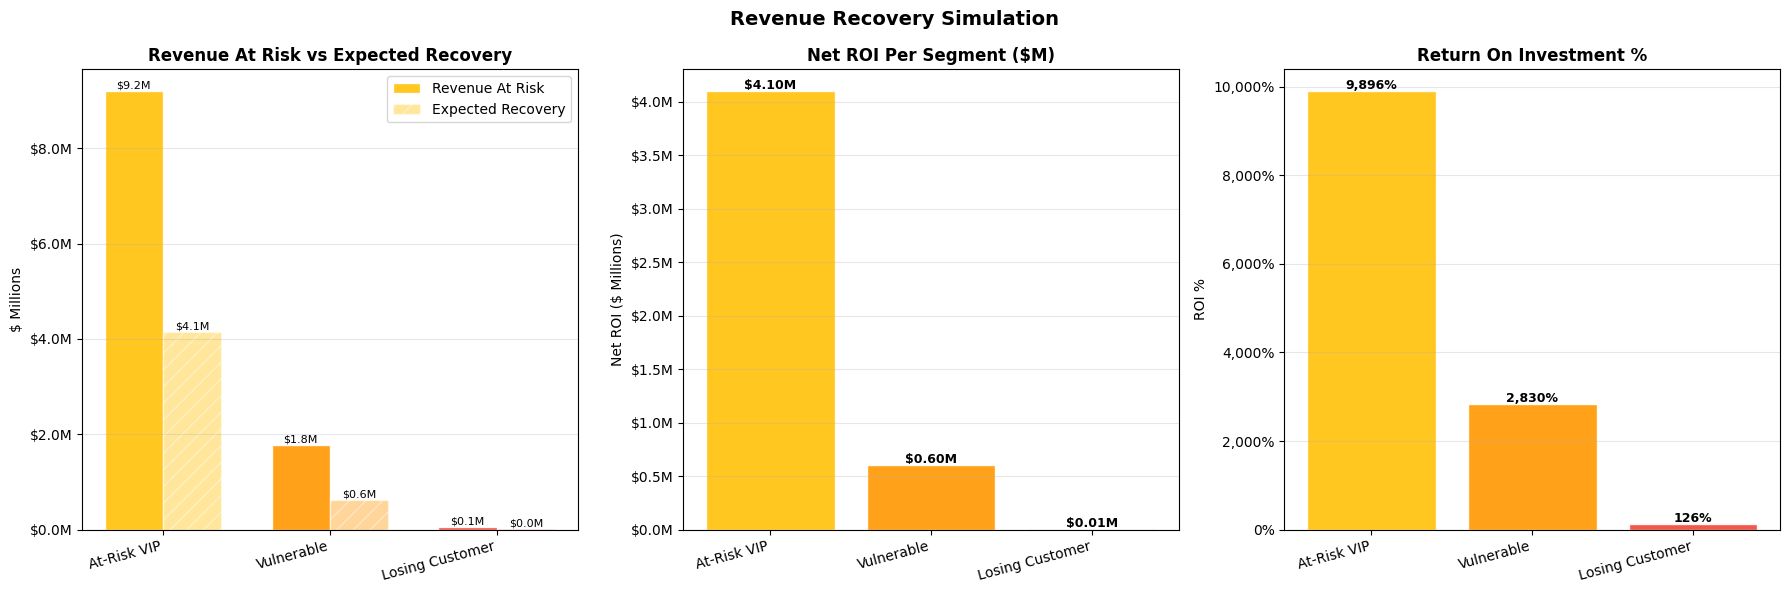

Saved → reports/revenue_recovery.png ✅


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Revenue Recovery Simulation",
    fontsize=14, fontweight="bold"
)

sim_plot = sim_df[sim_df["Segment"] != "TOTAL"].copy()

colors = [
    segment_colors["At-Risk VIP"],
    segment_colors["Vulnerable"],
    segment_colors["Losing Customer"]
]

# ── Chart 1 — Revenue At Risk vs Recovered ────────────
x     = np.arange(len(sim_plot))
width = 0.35

axes[0].bar(
    x - width/2,
    sim_plot["Revenue At Risk"] / 1e6,
    width, label="Revenue At Risk",
    color=colors, alpha=0.9,
    edgecolor="white"
)
axes[0].bar(
    x + width/2,
    sim_plot["Expected Recovery"] / 1e6,
    width, label="Expected Recovery",
    color=colors, alpha=0.4,
    edgecolor="white", hatch="//"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    sim_plot["Segment"],
    rotation=15, ha="right"
)
axes[0].set_title(
    "Revenue At Risk vs Expected Recovery",
    fontweight="bold"
)
axes[0].set_ylabel("$ Millions")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"${v:.1f}M")
)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

for i, (risk, rec) in enumerate(zip(
    sim_plot["Revenue At Risk"],
    sim_plot["Expected Recovery"]
)):
    axes[0].text(
        i - width/2, risk/1e6 + 0.05,
        f"${risk/1e6:.1f}M",
        ha="center", fontsize=8
    )
    axes[0].text(
        i + width/2, rec/1e6 + 0.05,
        f"${rec/1e6:.1f}M",
        ha="center", fontsize=8
    )

# ── Chart 2 — Net ROI $ ───────────────────────────────
bars = axes[1].bar(
    sim_plot["Segment"],
    sim_plot["Net ROI"] / 1e6,
    color=colors,
    edgecolor="white",
    alpha=0.9
)
axes[1].set_title(
    "Net ROI Per Segment ($M)",
    fontweight="bold"
)
axes[1].set_ylabel("Net ROI ($ Millions)")
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"${v:.1f}M")
)
axes[1].set_xticklabels(
    sim_plot["Segment"],
    rotation=15, ha="right"
)
axes[1].grid(axis="y", alpha=0.3)

for bar, val in zip(bars, sim_plot["Net ROI"]):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"${val/1e6:.2f}M",
        ha="center", fontsize=9,
        fontweight="bold"
    )

# ── Chart 3 — ROI % ───────────────────────────────────
bars = axes[2].bar(
    sim_plot["Segment"],
    sim_plot["ROI %"],
    color=colors,
    edgecolor="white",
    alpha=0.9
)
axes[2].set_title(
    "Return On Investment %",
    fontweight="bold"
)
axes[2].set_ylabel("ROI %")
axes[2].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v:,.0f}%")
)
axes[2].set_xticklabels(
    sim_plot["Segment"],
    rotation=15, ha="right"
)
axes[2].grid(axis="y", alpha=0.3)

for bar, val in zip(bars, sim_plot["ROI %"]):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f"{val:,.0f}%",
        ha="center", fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(
    "../reports/revenue_recovery.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved → reports/revenue_recovery.png ✅")

## Revenue Recovery Simulation — Key Observations

**Revenue at Risk vs Expected Recovery**

The analysis shows that **At-Risk VIP customers represent the largest revenue exposure**, with approximately **$9.2M in revenue at risk**. Based on the assumed recovery rate, **$4.1M of this revenue could potentially be retained** through targeted intervention strategies.

The **Vulnerable segment** contributes **$1.8M in revenue at risk**, with an estimated **$0.6M recoverable** through retention efforts.

In contrast, **Losing Customers represent only $0.1M in revenue exposure**, indicating that although intervention is still profitable, the financial impact is relatively small.

---

**Net ROI Per Segment**

The financial simulation compares the **campaign investment required for each segment** with the **expected revenue recovery**.

| Segment         | Campaign Cost | Net ROI    |
| --------------- | ------------- | ---------- |
| At-Risk VIP     | $41,400       | $4.10M     |
| Vulnerable      | $21,250       | $0.60M     |
| Losing Customer | $4,130        | $0.01M     |
| **Total**       | **$66,780**   | **$4.70M** |

A **total campaign investment of $66,780** is projected to generate **$4.70M in recovered revenue**, highlighting the extremely strong financial leverage of targeted retention initiatives.

---

**Return on Investment (ROI)**

The ROI analysis further reinforces the value of prioritising high-value customers:

* **At-Risk VIP → 9,896% ROI**
* **Vulnerable → 2,830% ROI**
* **Losing Customer → 126% ROI**

Even the lowest-performing segment produces a **positive return**, confirming that retention campaigns are financially viable across all segments. However, the **largest economic impact clearly comes from the At-Risk VIP segment**, where every dollar invested returns nearly **$100 in recovered revenue**.

---

### Overall Simulation Finding

The simulation demonstrates that **retention campaigns targeting high-value customers provide the greatest financial impact**.

Retaining just **45% of At-Risk VIP customers** through a **$41,400 intervention campaign** has the potential to recover **$4.1M in revenue**, making it the **highest-leverage retention opportunity identified in this analysis**.

These findings highlight the importance of **prioritising retention strategies based on both customer value and churn risk**, ensuring that marketing resources are allocated where they generate the greatest business return.


## Section 6 — Business Recommendations Cell:

In [10]:
print("=" * 65)
print("   SECTION 6 — BUSINESS RECOMMENDATIONS SUMMARY")
print("=" * 65)

recommendations = {
    "🟢 Champion": [
        "VIP loyalty programme — reward tenure",
        "Exclusive early access to new products",
        "Proactive relationship management",
        "Do NOT discount — protects margin",
    ],
    "🟡 At-Risk VIP": [
        "Immediate personalised outreach",
        "Premium retention offer — $50 budget",
        "Address cart abandonment friction",
        "Re-engage wishlist with price alerts",
    ],
    "🔵 Promising": [
        "Upsell to higher order value products",
        "Frequency incentives — buy 3 get 1",
        "Wishlist-based recommendations",
        "Convert to Champion tier focus",
    ],
    "🟠 Vulnerable": [
        "Standard retention offer — $25 budget",
        "Session re-engagement campaign",
        "Personalised product recommendations",
        "Monitor risk score weekly",
    ],
    "⚪ Hibernating": [
        "Automated low-touch email nurture",
        "Seasonal reactivation campaigns",
        "No significant budget allocation",
        "Monitor for segment migration",
    ],
    "🔴 Losing Customer": [
        "Low cost email win-back — $5 budget",
        "Single discount offer — last attempt",
        "Accept churn if no response",
        "Analyse exit patterns for model improvement",
    ],
}

for seg, actions in recommendations.items():
    print(f"\n  {seg}")
    print("  " + "-" * 45)
    for action in actions:
        print(f"    → {action}")

print("\n" + "=" * 65)
print("   PRIORITY ORDER FOR RETENTION BUDGET")
print("=" * 65)
print("""
  Priority 1 → At-Risk VIP   ROI 9,896%  $41,400
  Priority 2 → Vulnerable    ROI 2,830%  $21,250
  Priority 3 → Losing        ROI   126%   $4,130
  ─────────────────────────────────────────────
  Total Budget Required              :   $66,780
  Total Expected Revenue Recovered   : $4,770,124
  Net Return                         : $4,703,344
""")
print("=" * 65)

   SECTION 6 — BUSINESS RECOMMENDATIONS SUMMARY

  🟢 Champion
  ---------------------------------------------
    → VIP loyalty programme — reward tenure
    → Exclusive early access to new products
    → Proactive relationship management
    → Do NOT discount — protects margin

  🟡 At-Risk VIP
  ---------------------------------------------
    → Immediate personalised outreach
    → Premium retention offer — $50 budget
    → Address cart abandonment friction
    → Re-engage wishlist with price alerts

  🔵 Promising
  ---------------------------------------------
    → Upsell to higher order value products
    → Frequency incentives — buy 3 get 1
    → Wishlist-based recommendations
    → Convert to Champion tier focus

  🟠 Vulnerable
  ---------------------------------------------
    → Standard retention offer — $25 budget
    → Session re-engagement campaign
    → Personalised product recommendations
    → Monitor risk score weekly

  ⚪ Hibernating
  -------------------------------

## Section 7 — Exporting Segmented Customer Dataset

To operationalise the results of the churn and lifetime value models, the final customer dataset is exported as a **CSV file for business and marketing teams**.

This dataset combines the outputs from the predictive models with the segmentation framework, allowing non-technical stakeholders to directly identify which customers require retention intervention.

Each customer record in the exported dataset includes:

* **Customer ID** — Unique identifier for each customer
* **Predicted Churn Probability** — Likelihood that the customer will leave the service
* **Predicted Customer Lifetime Value (LTV)** — Estimated future revenue contribution
* **Composite Risk Score** — Combined metric derived from churn probability and predicted LTV
* **Customer Segment** — Final assigned segment (At-Risk VIP, Vulnerable, or Losing Customer)

By exporting this dataset, the machine learning outputs are translated into an **actionable business asset** that can be directly used for targeted marketing campaigns, retention strategy planning, and customer relationship management initiatives.

This step ensures that the analytical insights generated in the project can be **integrated into real-world business decision-making workflows**.


In [11]:
# ── Final Export of DataFrame ────────────────────────────
export_df = pred_df[[
    "Customer_ID",
    "Churn_Prob",
    "Predicted_LTV",
    "Risk_Score",
    "Segment",
]].copy()

export_df.columns = [
    "Customer_ID",
    "Churn_Probability",
    "Predicted_LTV",
    "Composite_Risk_Score",
    "Segment",
]

export_df = export_df.sort_values(
    "Composite_Risk_Score",
    ascending=False
).reset_index(drop=True)

export_df.to_csv(
    "../data/customer_segments.csv",
    index=False
)

# ── Verifying Export ─────────────────────────────────────
verify = pd.read_csv("../data/customer_segments.csv")

print("=" * 65)
print("   CUSTOMER SEGMENTS EXPORTED ✅")
print("=" * 65)
print(f"\n  File    : data/customer_segments.csv")
print(f"  Rows    : {len(verify):,}")
print(f"  Columns : {list(verify.columns)}")
print(f"\n  Segment Distribution:")
print("  " + "-" * 45)
for seg in segment_order:
    count = (verify["Segment"] == seg).sum()
    pct   = count / len(verify) * 100
    icon  = segment_icons[seg]
    print(f"  {icon} {seg:<20} {count:>6,}  ({pct:.1f}%)")

print(f"\n  Top 5 Highest Risk Customers:")
print("  " + "-" * 65)
print(f"  {'Customer_ID':<15} {'Risk Score':>12} "
      f"{'Churn Prob':>12} {'LTV':>12} {'Segment'}")
print("  " + "-" * 65)
for _, row in verify.head(5).iterrows():
    print(
        f"  {row['Customer_ID']:<15}"
        f" {row['Composite_Risk_Score']:>12.4f}"
        f" {row['Churn_Probability']:>12.4f}"
        f" ${row['Predicted_LTV']:>10,.2f}"
        f"  {row['Segment']}"
    )
print("=" * 65)
print("\n  Notebook Complete ✅")
print("=" * 65)

   CUSTOMER SEGMENTS EXPORTED ✅

  File    : data/customer_segments.csv
  Rows    : 10,000
  Columns : ['Customer_ID', 'Churn_Probability', 'Predicted_LTV', 'Composite_Risk_Score', 'Segment']

  Segment Distribution:
  ---------------------------------------------
  🟢 Champion              2,472  (24.7%)
  🟡 At-Risk VIP             828  (8.3%)
  🔵 Promising             2,550  (25.5%)
  🟠 Vulnerable              850  (8.5%)
  ⚪ Hibernating           2,474  (24.7%)
  🔴 Losing Customer         826  (8.3%)

  Top 5 Highest Risk Customers:
  -----------------------------------------------------------------
  Customer_ID       Risk Score   Churn Prob          LTV Segment
  -----------------------------------------------------------------
  CUST05075             0.9926       0.9931 $    109.65  Losing Customer
  CUST08844             0.9812       0.9979 $    114.09  Losing Customer
  CUST03429             0.9763       0.9801 $      0.00  Losing Customer
  CUST08282             0.9757       0.